<a href="https://colab.research.google.com/github/selvapreethi2006-hue/customer_purchase_dataset/blob/main/Customer_purchase_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [103]:
#Upload CSV File
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("Social_Network_Ads.csv")
print(df.head())

Saving Social_Network_Ads.csv to Social_Network_Ads (7).csv
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [116]:
#Understand the Data
print(df.shape)
print(df.columns)
print(df.dtypes)


(400, 6)
Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased', 'AgeGroup'], dtype='object')
User ID            int64
Gender             int64
Age                int64
EstimatedSalary    int64
Purchased          int64
AgeGroup           int64
dtype: object


In [105]:
#Clean the Data
print(df.isnull().sum())
df = df.dropna()
df = df.drop_duplicates()
print(df.shape)

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
(400, 5)


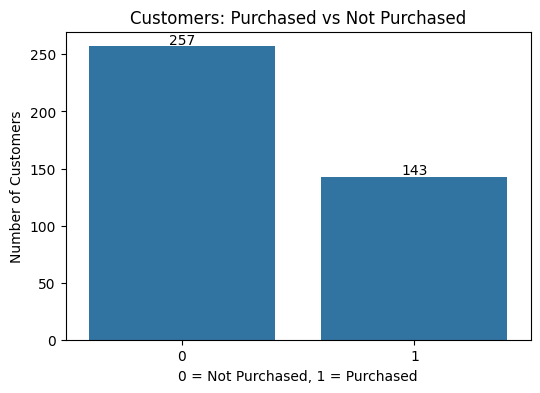

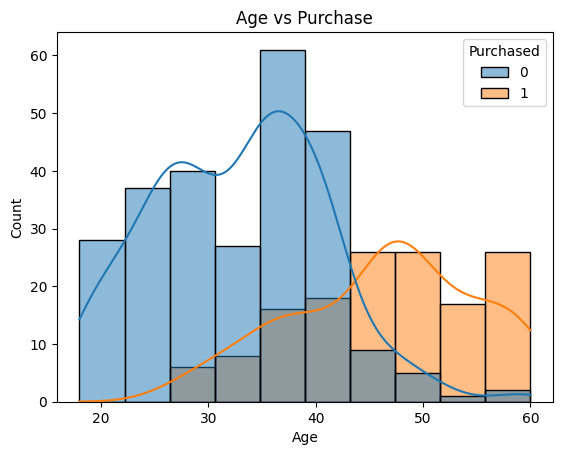

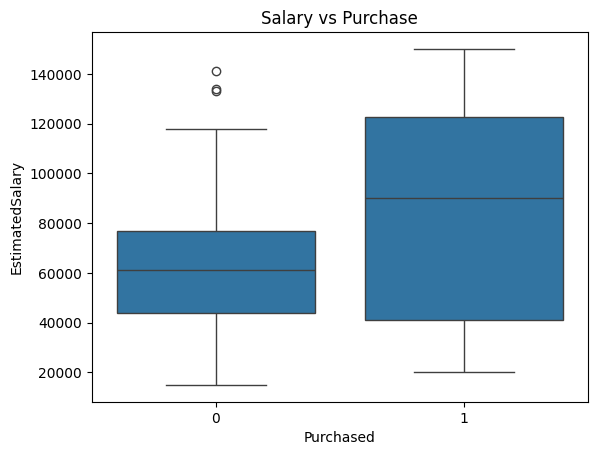

In [113]:
#EDA
counts = df['Purchased'].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(x='Purchased', data=df)
plt.title("Customers: Purchased vs Not Purchased")
plt.xlabel("0 = Not Purchased, 1 = Purchased")
plt.ylabel("Number of Customers")

for i, v in enumerate(counts):
    plt.text(i, v + 2, str(v), ha='center')

plt.show()

sns.histplot(data=df, x='Age', hue='Purchased', kde=True)
plt.title("Age vs Purchase")
plt.show()

sns.boxplot(x='Purchased', y='EstimatedSalary', data=df)
plt.title("Salary vs Purchase")
plt.show()


In [107]:
#Feature Engineering
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 25, 40, 60, 100],
                         labels=['Young', 'Adult', 'MiddleAge', 'Senior'])
print(df[['Age', 'AgeGroup']].head())


   Age AgeGroup
0   19    Young
1   35    Adult
2   26    Adult
3   27    Adult
4   19    Young


In [112]:
#Encode & Scale
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])          # Female=0, Male=1

le_agegroup = LabelEncoder()
df['AgeGroup'] = le_agegroup.fit_transform(df['AgeGroup'])    # encode age group

X = df.drop(['Purchased', 'User ID'], axis=1, errors='ignore')
y = df['Purchased']

print("Feature columns used:", list(X.columns))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Feature columns used: ['Gender', 'Age', 'EstimatedSalary', 'AgeGroup']


In [109]:
#Split the Data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42 #(Train-80,Test-20)
)
print(X_train.shape, X_test.shape)


(320, 4) (80, 4)


In [110]:
#Train Model
# Model 1: Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

# Model 2: Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
print("Decision Tree model trained successfully.")

Logistic Regression model trained successfully.
Decision Tree model trained successfully.


In [111]:
#Evaluate Model
models = [
    ("Logistic Regression", log_model),
    ("Decision Tree", tree_model)
]

results = []
for name, model in models:
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(f"\n=== {name} ===")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1})

results_df = pd.DataFrame(results)
print("\n=== MODEL COMPARISON ===")
print(results_df)


=== Logistic Regression ===
Accuracy : 0.8875
Precision: 0.9130434782608695
Recall   : 0.75
F1 Score : 0.8235294117647058
Confusion Matrix:
 [[50  2]
 [ 7 21]]

=== Decision Tree ===
Accuracy : 0.8125
Precision: 0.7407407407407407
Recall   : 0.7142857142857143
F1 Score : 0.7272727272727273
Confusion Matrix:
 [[45  7]
 [ 8 20]]

=== MODEL COMPARISON ===
                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression    0.8875   0.913043  0.750000  0.823529
1        Decision Tree    0.8125   0.740741  0.714286  0.727273
